In [2]:
import requests
import re
from bs4 import BeautifulSoup
import pandas as pd

page = '/page/1/'
data = []
while True:
    url = "http://quotes.toscrape.com" + page
    f = requests.get(url)
    soup = BeautifulSoup(f.content, 'html.parser')
    a = soup.find_all('div',{'class':'quote'})
    
    for el in a:
        quote = el.find('span',{'class':'text'}).text
        author = el.find('small',{'class':'author'}).text
        tags = []
        for tag in el.find('div',{'class':'tags'}).find_all('a'):
            temp = tag.text
            tags.append(temp)
        tags = ','.join(str(item) for item in tags)
        page_no = re.findall('\d+',page)[0]
        temp_tuple = (page_no,quote,author,tags)
        data.append(temp_tuple)
    
    if soup.find("li",{'class':'next'}) != None:
        page = soup.find("li",{'class':'next'}).find('a').get("href")
    else:
        break
        
df = pd.DataFrame(data = data, columns = ['Page','Quote','Author','Tags'])
df

,Page,Quote,Author,Tags
0,1,“The world as we have created it is a process ...,Albert Einstein,"change,deep-thoughts,thinking,world"
1,1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities,choices"
2,1,“There are only two ways to live your life. On...,Albert Einstein,"inspirational,life,live,miracle,miracles"
3,1,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy,books,classic,humor"
4,1,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself,inspirational"
...,...,...,...,...
95,10,“You never really understand a person until yo...,Harper Lee,better-life-empathy
96,10,“You have to write the book that wants to be w...,Madeleine L'Engle,"books,children,difficult,grown-ups,write,write..."
97,10,“Never tell the truth to people who are not wo...,Mark Twain,truth
98,10,"“A person's a person, no matter how small.”",Dr. Seuss,inspirational


<b>Q. What is the total count of valid pages in the aforementioned website that you could crawl?</b>

In [3]:
df['Page'] = df['Page'].astype(int)
df['Page'].max()

10

<b>Q. Provide a frequency distribution of the number of quotes per author</b>

In [4]:
no_quote_per_author = df.groupby('Author')['Quote'].count()
no_quote_per_author = no_quote_per_author.to_frame()
no_quote_per_author.reset_index(inplace=True)
no_quote_per_author

,Author,Quote
0,Albert Einstein,10
1,Alexandre Dumas fils,1
2,Alfred Tennyson,1
3,Allen Saunders,1
4,André Gide,1
5,Ayn Rand,1
6,Bob Marley,3
7,C.S. Lewis,5
8,Charles Bukowski,2
9,Charles M. Schulz,1


<b>Q. Provide a frequency distribution of the tags</b>

In [5]:
no_of_tags = {}
for el in df['Tags']:
    temp = el.split(',')
    for t in temp:
        if t not in no_of_tags:
            no_of_tags[t] = 1
        else:
            no_of_tags[t] += 1
no_of_tags

{'change': 1,
 'deep-thoughts': 1,
 'thinking': 2,
 'world': 1,
 'abilities': 1,
 'choices': 1,
 'inspirational': 13,
 'life': 13,
 'live': 1,
 'miracle': 1,
 'miracles': 1,
 'aliteracy': 1,
 'books': 11,
 'classic': 2,
 'humor': 12,
 'be-yourself': 1,
 'adulthood': 1,
 'success': 1,
 'value': 1,
 'love': 14,
 'edison': 1,
 'failure': 1,
 'paraphrased': 2,
 'misattributed-eleanor-roosevelt': 1,
 'obvious': 1,
 'simile': 3,
 'friends': 4,
 'heartbreak': 1,
 'sisters': 1,
 'courage': 2,
 'simplicity': 1,
 'understand': 1,
 'fantasy': 1,
 'navigation': 1,
 'activism': 1,
 'apathy': 1,
 'hate': 1,
 'indifference': 1,
 'opposite': 1,
 'philosophy': 2,
 'friendship': 5,
 'lack-of-friendship': 1,
 'lack-of-love': 1,
 'marriage': 1,
 'unhappy-marriage': 1,
 'contentment': 1,
 'fate': 1,
 'misattributed-john-lennon': 1,
 'planning': 1,
 'plans': 1,
 'poetry': 1,
 'happiness': 1,
 'attributed-no-source': 3,
 'religion': 2,
 'comedy': 1,
 'yourself': 2,
 'children': 2,
 'fairy-tales': 1,
 '': 3,


<b>Q. Plot the average length of quotes (no. of words) per author.</b>

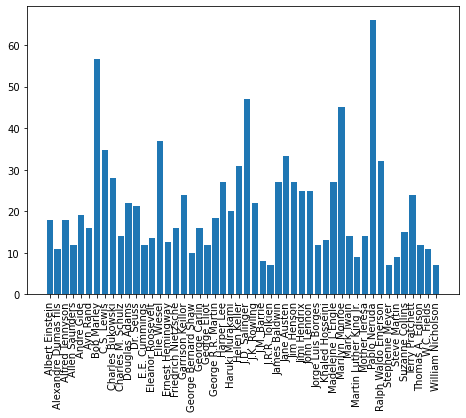

In [16]:
import matplotlib.pyplot as plt

a = df.groupby(['Author'])['Quote'].apply(' '.join).reset_index()
word_len = []
x = list(a.Quote.str.split(' '))
for el in x:
    word_len.append(len(el))
    
a['word_len'] = word_len
a['no_quote_per_author'] = no_quote_per_author['Quote']
a['avg_len'] = a['word_len']/a['no_quote_per_author']
#display(a)
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
Author = a['Author']
Avg_length_quote = a['avg_len']
ax.bar(Author,Avg_length_quote)
plt.xticks(rotation = 90)
plt.show()